### 1- Setup

In [1]:
!pip install mip

from mip import *
import math


[notice] A new release of pip is available: 23.3.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# resolve o modelo e mostra os valores das variáveis na solução
def solve(model):
  status = model.optimize(max_seconds=15)

  if status != OptimizationStatus.OPTIMAL:
    return

  print("Status = ", status)
  print(f"Solution value  = {model.objective_value:.2f}\n")

  print("Solution:")
  for v in model.vars:
      print(f"{v.name} = {v.x:.2f}")


# salva modelo em arquivo lp, e mostra o conteúdo
def save(model, filename):
  model.write(filename) # salva modelo em arquivo
  with open(filename, "r") as f: # lê e exibe conteúdo do arquivo
    print(f.read())

In [3]:
def read_instance(filename):
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f.readlines()]

    # skip comment lines
    idx = 0
    def next_data_line():
        nonlocal idx
        while idx < len(lines) and (lines[idx].startswith('#') or lines[idx] == ''):
            idx += 1
        data = lines[idx]
        idx += 1
        return data

    # First block: general info
    # nbVertices, maxArcId, nbElementaritySets, nbPackingSets, nbCoveringSets,
    # symmetricCase, backwardSearchIsUsed, zeroReducedCostThreshold
    parts = next_data_line().split()
    nb_vertices = int(parts[0])
    max_arc_id = int(parts[1])

    # Second block: resources info
    # nbMainResources, nbDisposableResources, nbStandardResources, bidirectionalBorderValue
    parts = next_data_line().split()
    nb_main_resources = int(parts[0])

    # The actual number of distinct resources in the file equals nb_main_resources
    nb_resources = nb_main_resources

    # Read vertex info
    lb = {}  # resource consumption lower bounds per vertex
    ub = {}  # resource consumption upper bounds per vertex
    for i in range(nb_vertices):
        parts = next_data_line().split()
        vert_alg_id = int(parts[0])

        # Resource bounds line: lb ub bucketStep (for each main resource)
        res_parts = next_data_line().split()
        pos = 0
        for r in range(nb_resources):
            lb[(vert_alg_id, r)] = float(res_parts[pos])
            ub[(vert_alg_id, r)] = float(res_parts[pos + 1])
            pos += 3  # lb, ub, bucketStep

        # nbInMemoryOfElemSets
        next_data_line()

    # Read arc info
    num_arcs_line = next_data_line()
    num_arcs = int(num_arcs_line.split()[0])

    arcs = []
    costs = {}
    resource_cost = {}
    for a in range(num_arcs):
        # arcId, tailVertAlgId, headVertAlgId, elemSetId, packSetId, covSetId, reducedCost, totalCost
        parts = next_data_line().split()
        arc_id = int(parts[0])
        tail = int(parts[1])
        head = int(parts[2])
        reduced_cost = float(parts[6])

        arcs.append((tail, head))
        costs[arc_id] = reduced_cost

        # resource consumption: one value per resource on a single line
        res_parts = next_data_line().split()
        for r in range(nb_resources):
            resource_cost[(arc_id, r)] = float(res_parts[r])

        # nbInMemoryOfElemSets
        next_data_line()
        # nbBuckArcIntrvs + intervals
        next_data_line()

    source = 0
    sink = nb_vertices - 1

    print(f"Instance: {filename}")
    print(f"  Vertices: {nb_vertices}, Arcs: {num_arcs}")
    print(f"  Source: {source}, Sink: {sink}")
    print(f"  Resources: {nb_resources}")
    print(f"  Arcs: {arcs}")
    print(f"  Costs: {costs}")
    print(f"  Resource costs: {resource_cost}")
    print(f"  LB: {lb}")
    print(f"  UB: {ub}")

    return arcs, resource_cost, costs, lb, ub, source, sink

In [4]:
# Adapt parsed instance into structures used below (dict-of-sets/dicts, lb/ub per vertex, ng_set)
# This cell assumes the reader has already populated: arcs, resource_cost, costs, lb, ub, source, sink

def adapt_instance_to_cell8(arcs, resource_cost, costs, lb, ub, source, sink):
    # create node labels as strings '0','1',... matching example which uses letters
    # We'll use string vertex ids (numbers) to avoid collisions with existing examples
    vertices = sorted({v for arc in arcs for v in arc})
    # Ensure source/sink included
    if source not in vertices:
        vertices.insert(0, source)
    if sink not in vertices:
        vertices.append(sink)

    # map vertex int -> str label
    vlabel = {v: str(v) for v in vertices}

    # arcs: dict node -> set(neighbors)
    arcs_dict = {vlabel[v]: set() for v in vertices}
    for arc_id, (t, h) in enumerate(arcs):
        arcs_dict[vlabel[t]].add(vlabel[h])

    # resource_cost and costs: dict node -> dict(neighbor -> value)
    resource_cost_dict = {vlabel[v]: {} for v in vertices}
    costs_dict = {vlabel[v]: {} for v in vertices}
    for arc_id, (t, h) in enumerate(arcs):
        tail = vlabel[t]
        head = vlabel[h]
        # use arc_id keys from costs/resource_cost
        # resource_cost keyed by (arc_id, r). We assume single resource r=0
        rc = resource_cost.get((arc_id, 0), 0.0)
        c = costs.get(arc_id, 0.0)
        resource_cost_dict[tail][head] = rc
        costs_dict[tail][head] = c

    # lb/ub expected as dict vertex->value (example had single resource per vertex)
    lb_dict = {}
    ub_dict = {}
    for (vert, r), val in lb.items():
        lb_dict[vlabel[vert]] = val
    for (vert, r), val in ub.items():
        ub_dict[vlabel[vert]] = val

    # ng_set: neighbor-exclusion sets, default empty sets; keep conservative default
    ng_set = {vlabel[v]: set() for v in vertices}

    source_label = vlabel[source]
    sink_label = vlabel[sink]

    # print a short summary for verification
    print("Adapted instance summary:")
    print("  vertices:", list(arcs_dict.keys()))
    print("  source:", source_label, " sink:", sink_label)
    print("  arcs:", {k: sorted(list(v)) for k, v in arcs_dict.items()})
    print("  sample resource_cost:", resource_cost_dict)
    print("  sample costs:", costs_dict)
    print("  lb:", lb_dict)
    print("  ub:", ub_dict)

    return arcs_dict, resource_cost_dict, costs_dict, lb_dict, ub_dict, ng_set, source_label, sink_label

### 2- Definindo problema

In [6]:
arcs_raw, resource_cost_raw, costs_raw, lb_raw, ub_raw, source_raw, sink_raw = read_instance("data/inst1.txt")

arcs, resource_cost, costs, lb, ub, ng_set, source, sink = adapt_instance_to_cell8(
    arcs_raw, resource_cost_raw, costs_raw, lb_raw, ub_raw, source_raw, sink_raw
)


Instance: data/inst1.txt
  Vertices: 6, Arcs: 10
  Source: 0, Sink: 5
  Resources: 1
  Arcs: [(0, 2), (0, 5), (1, 3), (1, 4), (2, 3), (2, 4), (3, 5), (4, 1), (4, 2), (4, 3)]
  Costs: {0: -2.3324577547721366, 1: -2.2816826729520647, 2: -2.8068573794444696, 3: -1.5145843909488972, 4: -1.4999039047611935, 5: -1.332466945377714, 6: -2.2985198969749625, 7: -1.3244035651261448, 8: -1.2804405496589484, 9: -1.0135715139508243}
  Resource costs: {(0, 0): 0.8465118941921904, (1, 0): 0.5082949723941692, (2, 0): 0.6223419944935695, (3, 0): 0.5064261354734879, (4, 0): 0.6959464210773157, (5, 0): 0.5359051831423998, (6, 0): 0.8051348833673526, (7, 0): 0.8363842404840083, (8, 0): 0.8073297823168222, (9, 0): 0.8643913331829619}
  LB: {(0, 0): 0.0, (1, 0): 18.86758405930121, (2, 0): 29.72973613255987, (3, 0): 19.972426594553966, (4, 0): 43.354968869843624, (5, 0): 0.0}
  UB: {(0, 0): 200.0, (1, 0): 114.027824016771, (2, 0): 122.83957861845434, (3, 0): 104.30249014985729, (4, 0): 137.61370513820145, (5,

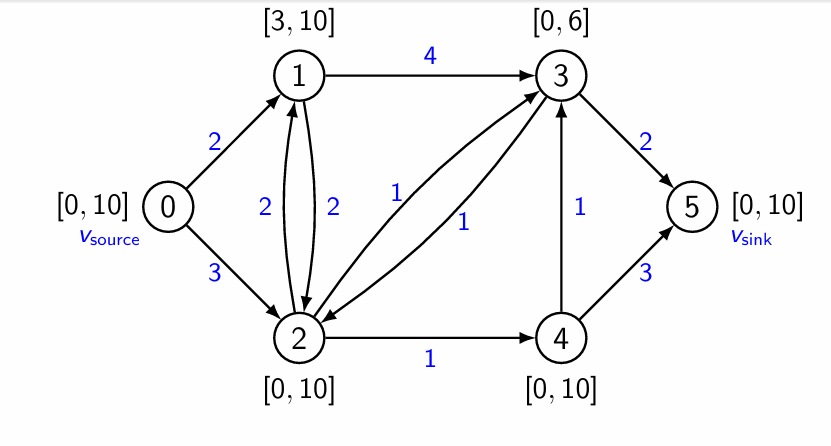

In [ ]:
arcs = {
  'A': {'B', 'C'},
  'B': {'C', 'D'},
  'C': {'B', 'D', 'E'},
  'D': {'C', 'F'},
  'E': {'F'},
  'F': {},
}

resource_cost = {
  'A': {'B': 2, 'C': 3},
  'B': {'C': 2, 'D': 4},
  'C': {'B': 2, 'D': 1, 'E': 1},
  'D': {'C': 1, 'F': 2},
  'E': {'F': 3},
  'F': {},
}

costs = {
  'A': {'B': 2, 'C': 3},
  'B': {'C': 2, 'D': 4},
  'C': {'B': 2, 'D': 1, 'E': 1},
  'D': {'C': 1, 'F': 2},
  'E': {'F': 3},
  'F': {},
}

# costs = {
#   'A': {'B': -1, 'C': -1},
#   'B': {'C': -1, 'D': -1},
#   'C': {'B': -1, 'D': -1, 'E': -1},
#   'D': {'C': -1, 'F': -1},
#   'E': {'F': -1},
#   'F': {},
# }

lb = {
  'A': 0,
  'B': 3,
  'C': 0,
  'D': 0,
  'E': 0,
  'F': 0,
}

ub = {
  'A': 10,
  'B': 10,
  'C': 10,
  'D': 6,
  'E': 10,
  'F': 10,
}

# ub = {
#   'A': 20,
#   'B': 20,
#   'C': 20,
#   'D': 20,
#   'E': 20,
#   'F': 20,
# }

ng_set = {
  'A': {},
  'B': {'B', 'C', 'D'},
  'C': {'B', 'C', 'D', 'E'},
  'D': {'B', 'C', 'D', 'E'},
  'E': {'C'},
  'F': {},
}

# ng_set = {
#   'A': {},
#   'B': {},
#   'C': {},
#   'D': {},
#   'E': {},
#   'F': {},
# }

source = 'A'
sink = 'F'

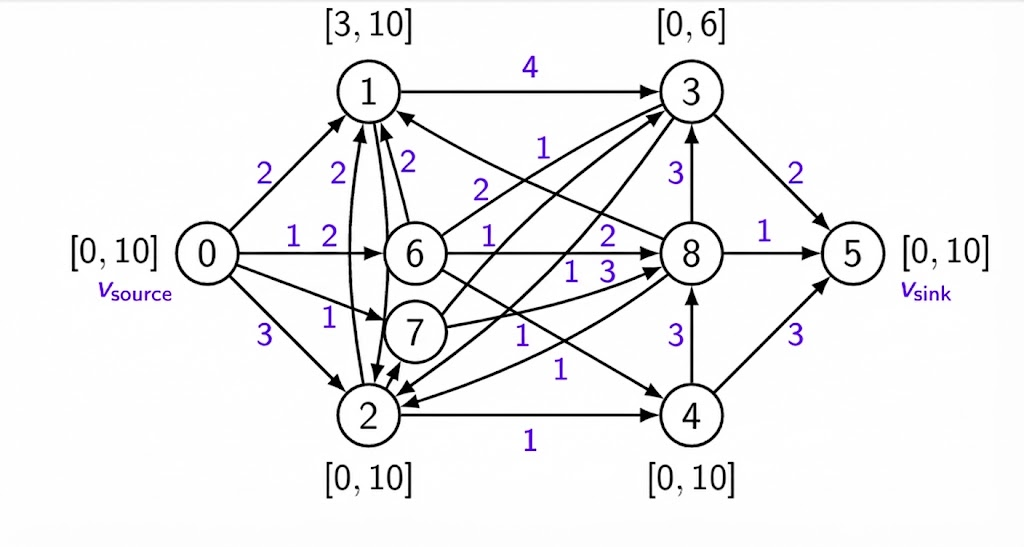

In [68]:
arcs = {
    'A': {'B', 'C', 'G', 'H'},
    'B': {'C', 'D', 'I'},
    'C': {'B', 'E'},
    'D': {'C', 'F'},
    'E': {'D', 'F'},
    'F': {},
    'G': {'B', 'C', 'I'},
    'H': {'C', 'D', 'I'},
    'I': {'D', 'E', 'F'}
}

resource_cost = {
    'A': {'B': 2, 'C': 3, 'G': 1, 'H': 1},
    'B': {'C': 2, 'D': 4, 'I': 2},
    'C': {'B': 2, 'E': 1},
    'D': {'C': 1, 'F': 2},
    'E': {'D': 3, 'F': 3},
    'F': {},
    'G': {'B': 2, 'C': 1, 'I': 1},
    'H': {'C': 2, 'D': 1, 'I': 3},
    'I': {'D': 3, 'E': 3, 'F': 1}
}

# costs = {
#     'A': {'B': 2, 'C': 3, 'G': 1, 'H': 1},
#     'B': {'C': 2, 'D': 4, 'I': 2},
#     'C': {'B': 2, 'E': 1},
#     'D': {'C': 1, 'F': 2},
#     'E': {'D': 3, 'F': 3},
#     'F': {},
#     'G': {'B': 2, 'C': 1, 'I': 1},
#     'H': {'C': 2, 'D': 1, 'I': 3},
#     'I': {'D': 3, 'E': 3, 'F': 1}
# }

costs = {
    'A': {'B': 2, 'C': 3, 'G': 10, 'H': 1},
    'B': {'C': -1, 'D': 4, 'I': 2},
    'C': {'B': -1, 'E': 1},
    'D': {'C': 1, 'F': 2},
    'E': {'D': 3, 'F': 3},
    'F': {},
    'G': {'B': 2, 'C': 1, 'I': 1},
    'H': {'C': 2, 'D': 1, 'I': 3},
    'I': {'D': 3, 'E': 3, 'F': 1}
}

lb = {
    'A': 0, 'B': 3, 'C': 0, 'D': 0, 'E': 0, 
    'F': 0, 'G': 0, 'H': 0, 'I': 0
}

ub = {
    'A': 10, 'B': 10, 'C': 10, 'D': 6, 'E': 10, 
    'F': 10, 'G': 10, 'H': 10, 'I': 10
}

ng_set = {
  'A': {},
  'B': {},
  'C': {}, #'B' ja quebra o loop
  'D': {},
  'E': {},
  'F': {},
  'G': {},
  'H': {},
  'I': {}
}

source = 'A'
sink = 'F'

### 3- Estruturas Base

In [7]:
class RCSP:

  def __init__(self, arcs, resource_cost, costs, lb, ub, ng_set, source, sink):
    self.arcs = arcs
    self.resource_cost = resource_cost
    self.costs = costs
    self.lb = lb
    self.ub = ub
    self.ng_set = ng_set
    self.source = source
    self.sink = sink

    self.M = 100

    # vão ser preenchidos quando você chamar replicate_graph_complete()
    self.new_arcs: Dict[str, Set[str]] = {}
    self.new_costs: Dict[str, Dict[str, Any]] = {}
    self.new_resource_cost: Dict[str, Dict[str, Any]] = {}
    self.new_lb: Dict[str, Any] = {}
    self.new_ub: Dict[str, Any] = {}
    self.rep: Dict[str, list[str]] = {}

  def delta_minus(self, arcs, objective):
    result = []
    for i, v in arcs.items():
      for j in v:
        if j == objective:
          result.append(i)
    return result

  def delta_plus(self, arcs, objective):
    result = []
    for i, v in arcs.items():
      for j in v:
        if i == objective:
          result.append(j)
    return result

  def check_original(self, objective):
    for i,v in self.rep.items():
      for j in v:
        if j == objective:
          return i

  def calculate_clones(self):
    # soma do menor custo de entrada e menor custo de saída por nó
    d = dict()

    for arc in self.arcs:
      if arc == self.source or arc == self.sink:
        continue

      min_in = self.M
      enter = self.delta_minus(self.arcs, arc)
      for i in enter:
        min_in = min(min_in, self.resource_cost[i][arc])

      min_out = self.M
      exit = self.delta_plus(self.arcs, arc)
      for i in exit:
        min_out = min(min_out, self.resource_cost[arc][i])

      d[arc] = max(math.ceil(self.ub[arc] / (min_in + min_out)), 1)

    return d

  from typing import Dict, List, Tuple

  def replicate_graph_complete(self):
    clone_counts = self.calculate_clones()

    # 1) Ordem original dos nós: a ordem de inserção das chaves do dict é estável em Python 3.7+
    nodes: List[str] = list(self.arcs.keys())
    node_order = {n: i for i, n in enumerate(nodes)}  # pra ordenar vizinhos de forma determinística

    # internos na ordem original
    internal = [v for v in nodes if v not in {self.source, self.sink}]

    # mapeia nó original -> lista de réplicas (ou ele mesmo p/ source/sink)
    rep: Dict[str, List[str]] = {self.source: [self.source], self.sink: [self.sink]}
    for v in internal:
      k = clone_counts.get(v, 1)
      rep[v] = [f"{v}{i}" for i in range(1, k + 1)]

    # 2) new_nodes em lista, preservando ordem:
    #    source, depois internos (com suas réplicas), depois sink (se existirem nessa ordem no nodes, melhor respeitar nodes)
    new_nodes: List[str] = []
    for v in nodes:
      new_nodes.extend(rep[v])

    # 3) cria estruturas novas preservando ordem de iteração
    self.new_arcs = {v: [] for v in new_nodes}           # lista para manter ordem dos vizinhos
    self.new_costs = {v: {} for v in new_nodes}
    self.new_resource_cost = {v: {} for v in new_nodes}
    self.new_lb = {}
    self.new_ub = {}
    self.rep = rep

    # bounds (ordem estável)
    for v in nodes:
      for rv in rep[v]:
        self.new_lb[rv] = self.lb[v]
        self.new_ub[rv] = self.ub[v]

    # helper: adiciona aresta preservando ordem e sem duplicar
    def add_arc(ru: str, rv: str, u: str, v: str):
      # evita duplicata mantendo lista (O(d)), mas mantém ordem
      if rv not in self.new_arcs[ru]:
        self.new_arcs[ru].append(rv)
      self.new_costs[ru][rv] = self.costs[u][v]
      self.new_resource_cost[ru][rv] = self.resource_cost[u][v]

    # helper: iteração de vizinhos com ordem determinística
    def iter_neighbors(u: str):
      neigh = self.arcs.get(u, [])
      if isinstance(neigh, (list, tuple)):
        return neigh
      # se for set (ou qualquer iterável sem ordem), ordenar pelo node_order
      return sorted(neigh, key=lambda x: node_order.get(x, 10**9))

    # arestas na ordem dos nós + ordem dos vizinhos
    for u in nodes:
      for v in iter_neighbors(u):
        pairs: List[Tuple[str, str]] = []

        if u == self.source and v not in {self.source, self.sink}:
          pairs = [(self.source, rv) for rv in rep[v]]

        elif v == self.sink and u not in {self.source, self.sink}:
          pairs = [(ru, self.sink) for ru in rep[u]]

        elif u not in {self.source, self.sink} and v not in {self.source, self.sink}:
          pairs = [(ru, rv) for ru in rep[u] for rv in rep[v]]

        else:
          pairs = [(ru, rv) for ru in rep[u] for rv in rep[v]]

        for ru, rv in pairs:
          add_arc(ru, rv, u, v)


In [8]:
def retrieve_path(model):
  # get only used arcs
  used_arcs = list()
  for var in model.vars:
    if var.name.startswith("x"):
      if var.x == 1:
        used_arcs.append(var.name)

  # get path
  path = ["A"]
  entry = "A"
  while len(used_arcs):
    for name in used_arcs:
      if name.split("x_")[1].startswith(entry):
        entry = name.split("x_")[1].split("_")[1]
        path.append(entry[0])
        used_arcs.remove(name)
        break

  return path

def check_ng_set(rcsp, model):

  path = retrieve_path(model)

  memory = set()

  for node in path:
    if node in memory:
      return False
    removed_nodes = list()
    for known_node in memory:
      if known_node not in rcsp.ng_set[node]:
        removed_nodes.append(known_node)
    for removed_node in removed_nodes:
      memory.remove(removed_node)
    memory.add(node)

  return True

def retrieve_path_cplex(model, solution):
  # get only used arcs
  used_arcs = list()
  for var in model.iter_variables():
    if var.name.startswith("x"):
      if solution.get_value(var) == 1:
        used_arcs.append(var.name)

  # get path
  path = ["A"]
  entry = "A"
  while len(used_arcs):
    for name in used_arcs:
      if name.split("x_")[1].startswith(entry):
        entry = name.split("x_")[1].split("_")[1]
        path.append(entry[0])
        used_arcs.remove(name)
        break

  return path

def check_ng_set_cplex(rcsp, model, solution):

  path = retrieve_path_cplex(model, solution)

  memory = set()

  for node in path:
    if node in memory:
      return False
    removed_nodes = list()
    for known_node in memory:
      if known_node not in rcsp.ng_set[node]:
        removed_nodes.append(known_node)
    for removed_node in removed_nodes:
      memory.remove(removed_node)
    memory.add(node)

  return True

### 4- Modelando o Problema

In [9]:
rcsp = RCSP(arcs=arcs, resource_cost=resource_cost, costs=costs, lb=lb, ub=ub, ng_set=ng_set, source=source, sink=sink)
rcsp.replicate_graph_complete()

model = Model(sense=MINIMIZE, solver_name=CBC)
x = {i: {j: model.add_var(var_type=BINARY, name=f"x_{i}_{j}") for j in v} for i, v in rcsp.new_arcs.items()} # x['A1']['B2']
y = {i: model.add_var(var_type=CONTINUOUS, name=f"y_{i}", lb=0.0) for i, v in rcsp.new_arcs.items()} # y['A1']
z = {i: {j: model.add_var(var_type=BINARY, name=f"z_{i}_{j}") for j in rcsp.arcs.keys()} for i in rcsp.new_arcs.keys()} # x['A']['B']


# Lower bound
for i in rcsp.new_arcs:
  model += y[i] >= rcsp.new_lb[i]*xsum(x[j][i] for j in rcsp.delta_minus(rcsp.new_arcs, i)) # não sei se precisa desse somatório aqui

# Upper bound
for i in rcsp.new_arcs:
  model += y[i] <= rcsp.new_ub[i]

# Resources
for i, v in rcsp.new_arcs.items():
  for j in v:
    model += y[j] >= y[i] - rcsp.M*(1 - x[i][j]) + rcsp.new_resource_cost[i][j]

# Only 1 exits
for i in rcsp.new_arcs:
  model += xsum(x[i][j] for j in rcsp.delta_plus(rcsp.new_arcs, i)) <= 1

# Only 1 enters
for j in rcsp.new_arcs:
  model += xsum(x[i][j] for i in rcsp.delta_minus(rcsp.new_arcs, j)) <= 1

# Enters = Exits
for j in rcsp.new_arcs:
  if j == rcsp.source or j == rcsp.sink:
    continue
  model += xsum(x[i][j] for i in rcsp.delta_minus(rcsp.new_arcs, j)) - xsum(x[j][k] for k in rcsp.delta_plus(rcsp.new_arcs, j)) == 0

# Source
model += xsum(x[rcsp.source][j] for j in rcsp.delta_plus(rcsp.new_arcs, rcsp.source)) == 1

# Sink
model += xsum(x[i][rcsp.sink] for i in rcsp.delta_minus(rcsp.new_arcs, rcsp.sink)) == 1

# Replicando nos (acho que não precisa porque o grafo não é completo, já não existem arcos de um nó para suas réplicas)

# Proibindo ciclos
for i, v in rcsp.new_arcs.items():
  for j in v:
    if i == rcsp.source or j == rcsp.sink:
      continue
    model += x[i][j] <= 1 - z[i][rcsp.check_original(j)]

# Proibindo ciclos
for i, v in rcsp.new_arcs.items():
  for j in v:
    if i == rcsp.source or j == rcsp.sink:
      continue
    for k in rcsp.ng_set[rcsp.check_original(j)]:
      model += z[j][k] >= z[i][k] - (1 - x[i][j])

# Proibindo ciclos
for i in rcsp.new_arcs.keys():
  if i == rcsp.source or i == rcsp.sink:
    continue
  model += z[i][rcsp.check_original(i)] == 1

# Objetivo
model.objective = xsum(rcsp.new_costs[i][j]*x[i][j] for i, v in rcsp.new_arcs.items() for j in v)

# save(model, "model_test.lp")
# solve(model)

# model.verbose = 1
# model.max_mip_gap = 0.01
model.store_search_progress_log = True
print("cols:", model.num_cols, "rows:", model.num_rows)
# status = model.optimize(max_seconds=7200)
# print(status, model.num_solutions, model.objective_value if model.num_solutions else None)

model.write("model.lp")
# !cbc model.lp solve -seconds 10 -printingOptions all

cols: 60711 rows: 118389


In [10]:
model.search_progress_log.log

[]

In [11]:
print(retrieve_path(model))
print(check_ng_set(rcsp, model))

['A']
True


In [12]:
# print("Status = ", status)
# print(f"Solution value  = {model.objective_value:.2f}\n")

# print("Solution:")
# for v in model.vars:
#     print(f"{v.name} = {v.x:.2f}")

In [13]:
from docplex.mp.model_reader import ModelReader

mdl = ModelReader.read("model.lp")   # or "model.mps"
sol = mdl.solve(log_output=True)

if sol is None:
    print("No solution (infeasible/unbounded or solve failed).")
else:
    print("Objective:", sol.objective_value)

    # Example: access variable values
    for v in mdl.iter_variables():
        if abs(sol.get_value(v)) > 1e-9:
            print(v.name, sol.get_value(v))

Version identifier: 20.1.0.0 | 2020-11-10 | 9bedb6d68
CPXPARAM_Read_DataCheck                          1
Found incumbent of value -2.281680 after 0.01 sec. (8.42 ticks)
Tried aggregator 2 times.
MIP Presolve eliminated 59071 rows and 1101 columns.
MIP Presolve modified 63028 coefficients.
Aggregator did 74 substitutions.
Reduced MIP has 59168 rows, 58413 columns, and 402352 nonzeros.
Reduced MIP has 58131 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.25 sec. (400.46 ticks)
Probing time = 0.30 sec. (30.97 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 59168 rows, 58413 columns, and 402352 nonzeros.
Reduced MIP has 58131 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 9.62 sec. (10434.98 ticks)
Probing time = 0.19 sec. (29.08 ticks)
Clique table members: 6952.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: deterministic, using up to 16 threads.
Root relaxation solution time =

In [ ]:
output_filename = "solution_values.txt"

with open(output_filename, "w") as f:
    f.write(f"Objective value: {sol.objective_value}\n")
    f.write("Variable Solutions:\n")

    for v in mdl.iter_variables():
        val = sol.get_value(v)
        f.write(f"{v.name}: {val}\n")

print(f"Solution saved to {output_filename}")

Solution saved to solution_values.txt


In [ ]:
print(retrieve_path_cplex(mdl, sol))
print(check_ng_set_cplex(rcsp, mdl, sol))

['A', 'B', 'C', 'B', 'I', 'F']
True
